# House Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [3]:
data = pd.read_csv('house_data.csv')

data

,Area,Bedrooms,Bathrooms,Age,Price
0,1000,2,1,10,250000
1,1200,3,2,8,320000
2,1500,3,2,5,400000
3,1800,4,3,4,500000
4,2000,4,3,2,550000
5,2200,5,4,1,620000
6,2500,5,4,3,700000
7,2800,6,5,2,820000
8,3000,6,5,1,900000
9,3500,7,6,1,1100000


In [4]:
data.head()

,Area,Bedrooms,Bathrooms,Age,Price
0,1000,2,1,10,250000
1,1200,3,2,8,320000
2,1500,3,2,5,400000
3,1800,4,3,4,500000
4,2000,4,3,2,550000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       30 non-null     int64
 1   Bedrooms   30 non-null     int64
 2   Bathrooms  30 non-null     int64
 3   Age        30 non-null     int64
 4   Price      30 non-null     int64
dtypes: int64(5)
memory usage: 1.3 KB


Text(0.5, 1.0, 'Area vs Price')

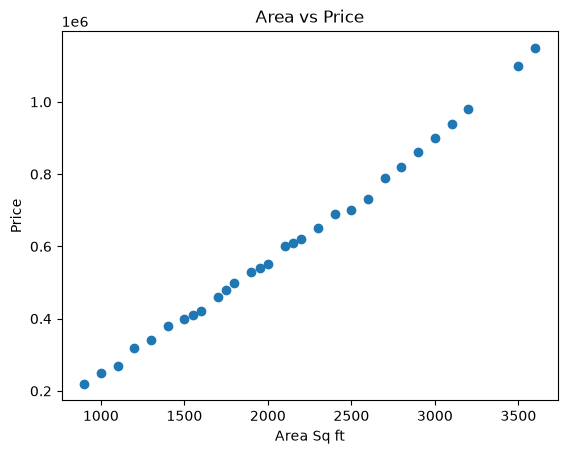

In [7]:
plt.scatter(data["Area"], data["Price"])

plt.xlabel("Area Sq ft")
plt.ylabel("Price")
plt.title("Area vs Price")

In [10]:
x = data[["Area", "Bedrooms", "Bathrooms", "Age"]]

y = data["Price"]

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [13]:
model = LinearRegression()

In [14]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
predictions = model.predict(x_test)

predictions

array([ 803708.34962847,  583855.88580368,  483993.93820884,
        772353.6370747 ,  902647.53617521, 1080943.19515057])

In [18]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)



In [19]:
mae

16317.396688828108

In [20]:
rmse

np.float64(20930.458855696)

In [21]:
r2

0.9890812601185548

In [22]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions})

result

,Actual Price,Predicted Price
27,790000,8.037083e+05
15,600000,5.838559e+05
23,480000,4.839939e+05
17,730000,7.723536e+05
8,900000,9.026475e+05
9,1100000,1.080943e+06


Text(0.5, 1.0, 'Actual Price vs Predicted Price')

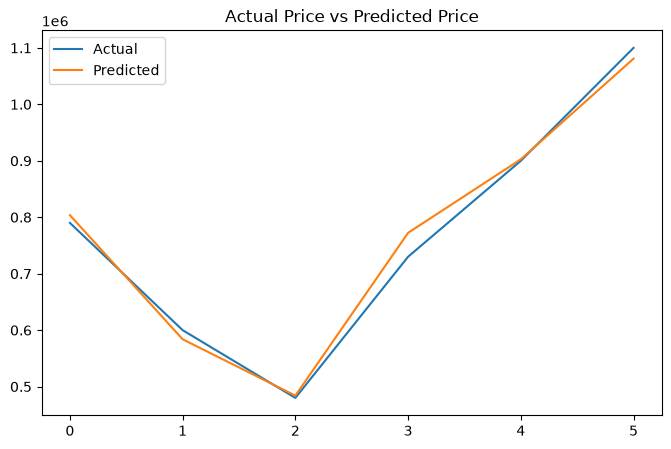

In [23]:
plt.figure(figsize=(8,5))

plt.plot(result['Actual Price'].values, label="Actual")

plt.plot(result['Predicted Price'].values, label="Predicted")

plt.legend()

plt.title("Actual Price vs Predicted Price")

In [24]:
joblib.dump(model, "house_price_prediction.pkl")

['house_price_prediction.pkl']

In [26]:
saved_model = joblib.load("house_price_prediction.pkl")

In [33]:
predict = saved_model.predict([[2000, 4, 3, 2]])

predict

C:\Users\91801\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([552494.23152131])